In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## formula: y=m*x+b

In [2]:
df=pd.read_csv("data/home_prices.csv")
df.head()

,locality,area_sqr_ft,price_lakhs,bedrooms
0,Kollur,656,39.0,2
1,Kollur,1260,83.2,2
2,Kollur,1057,86.6,3
3,Kollur,1259,59.0,2
4,Kollur,1800,140.0,3


In [103]:
df.dtypes

locality           str
area_sqr_ft      int64
price_lakhs    float64
bedrooms         int64
dtype: object

In [62]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(df[['area_sqr_ft']],df.price_lakhs)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [63]:
scope=model.coef_

In [64]:
model.predict([[2000]])

C:\Users\Jeevan kumar\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([222.43506959])

In [65]:
inter=model.intercept_

In [66]:
(scope*2000)+inter

array([222.43506959])

In [67]:
model.score(df[['area_sqr_ft']],df.price_lakhs)

0.8689469294004183

In [68]:
from sklearn.model_selection import train_test_split
x_test,x_train,y_test,y_train=train_test_split(df[['area_sqr_ft']],df.price_lakhs,test_size=0.2)


In [69]:
model_score=model.score(x_test,y_test)
model_score

0.8785448973860934

In [70]:
std,mean=df.price_lakhs.std(),df.price_lakhs.mean()
std,mean

(np.float64(98.24033840998865), np.float64(129.31363636363633))

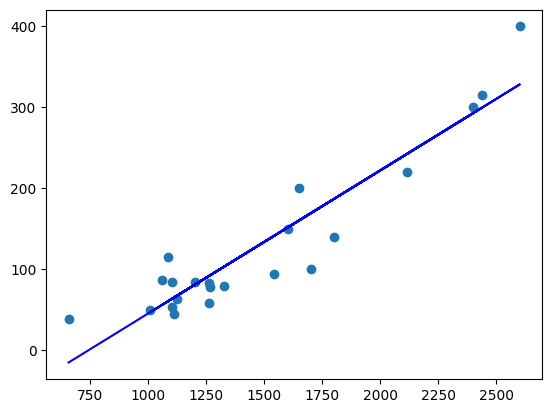

In [71]:
plt.scatter(df.area_sqr_ft,df.price_lakhs)
plt.plot(df.area_sqr_ft,model.predict(df[['area_sqr_ft']]),color='b')

{'whiskers': [<matplotlib.lines.Line2D at 0x1b686c03b10>,
 'caps': [<matplotlib.lines.Line2D at 0x1b686c03d90>,
 'boxes': [<matplotlib.lines.Line2D at 0x1b686c039d0>],
 'medians': [<matplotlib.lines.Line2D at 0x1b686c3c050>],
 'fliers': [<matplotlib.lines.Line2D at 0x1b686c3c190>],
 'means': []}

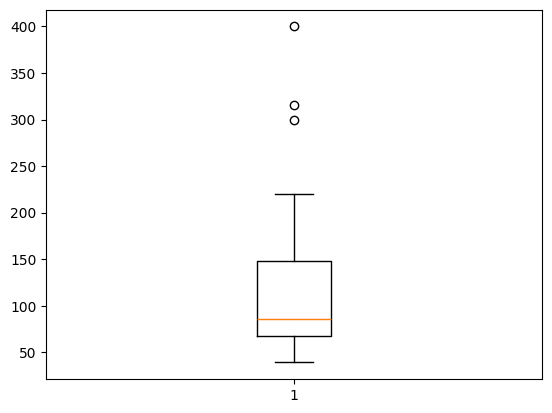

In [72]:
plt.boxplot(df.price_lakhs)

In [87]:
df['z_score']=(df.price_lakhs-mean)/std

In [88]:
df[df['z_score']>2]

,area_sqr_ft,price_lakhs,bedrooms,z_score


<h1>multiple linear regression</h1>

## formula= m1*x1+m2*x3+.....b

In [89]:
df=pd.read_csv(r"C:\Users\Jeevan kumar\Downloads\ML_Regression_MultipleLinearRegression_resources\home_prices.csv")
df.head()

,area_sqr_ft,price_lakhs,bedrooms
0,656,39.0,2
1,1260,83.2,2
2,1057,86.6,3
3,1259,59.0,2
4,1800,140.0,3


In [90]:
linear_model=LinearRegression()

In [9]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df[['area_sqr_ft','bedrooms']],df.price_lakhs,test_size=0.2)

KeyError: "None of [Index(['area_sqr_ft', 'bedrooms'], dtype='str')] are in the [columns]"

In [92]:
linear_model.fit(x_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [93]:
linear_model.score(x_test,y_test)

-1.9811294965297903

In [94]:
linear_model.predict([[1500,2]])

C:\Users\Jeevan kumar\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([81.93088304])

In [95]:
test=pd.DataFrame({'area_sqr_ft':[1500,2000],'bedrooms':[2,3]})
linear_model.predict(test)

array([ 81.93088304, 129.85777986])

In [96]:
s,intercept=linear_model.coef_,linear_model.intercept_
s,intercept

(array([ 0.04364057, 26.10661283]), np.float64(-35.74319459017114))

In [97]:
linear_model.coef_[0]*1500+linear_model.coef_[1]*2+linear_model.intercept_

np.float64(81.93088304068114)

<h1>one hot encoding</h1>

In [104]:
df.columns

Index(['locality', 'area_sqr_ft', 'price_lakhs', 'bedrooms'], dtype='str')

In [107]:
df_encoded=pd.get_dummies(df,columns=['locality'],drop_first=True,dtype=int)
df_encoded.sample(5)

,area_sqr_ft,price_lakhs,bedrooms,locality_Kollur,locality_Mankhal
6,1085,116.0,3,1,0
17,1125,64.0,2,0,1
5,1325,80.1,2,1,0
3,1259,59.0,2,1,0
0,656,39.0,2,1,0


In [108]:
model2=LinearRegression()

In [113]:
x_train,x_test,y_train,y_test=train_test_split(df_encoded.drop('price_lakhs',axis=1),df_encoded.price_lakhs,test_size=0.2)

In [114]:
model2.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [115]:
model2.predict([[1085,3,1,0]])

C:\Users\Jeevan kumar\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([78.71825388])

In [116]:
model2.score(x_test,y_test)

0.8292805780574566

<h1>polynomial regression</h1>

In [5]:
df=pd.read_csv(r"C:\Users\Jeevan kumar\Videos\dataset\car_prices.csv")
df.sample(5)

,car_id,mileage,selling_price
259,A260,137874,8545
93,A094,53984,16299
222,A223,75467,11400
57,A058,125174,7559
26,A027,164765,7475


In [22]:
df.dtypes

car_id             str
mileage          int64
selling_price    int64
dtype: object

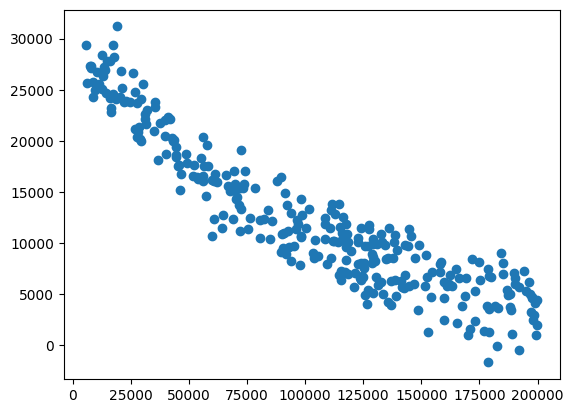

In [7]:
plt.scatter(df.mileage,df.selling_price)

In [25]:
x=df[['mileage']]
y=df.selling_price

In [26]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [27]:
from sklearn.preprocessing import PolynomialFeatures

In [39]:
poly=PolynomialFeatures(degree=3)
x_poly=poly.fit_transform(x_train)
x_test_poly=poly.transform(x_test)

In [40]:
x_train[:5]

,mileage
232,111081
59,129358
6,59886
185,145546
173,151779


In [41]:
x_poly[:5]

array([[1.00000000e+00, 1.11081000e+05, 1.23389886e+10, 1.37062719e+15],
       [1.00000000e+00, 1.29358000e+05, 1.67334922e+10, 2.16461108e+15],
       [1.00000000e+00, 5.98860000e+04, 3.58633300e+09, 2.14771138e+14],
       [1.00000000e+00, 1.45546000e+05, 2.11836381e+10, 3.08319379e+15],
       [1.00000000e+00, 1.51779000e+05, 2.30368648e+10, 3.49651231e+15]])

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

In [43]:
model=LinearRegression()
model.fit(x_poly,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [44]:
y_pred=model.predict(x_test_poly)

In [45]:
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
mse,r2

(4653180.72540464, 0.9187052046566796)

In [46]:
x_range=np.linspace(x['mileage'].min(),x['mileage'].max(),300).reshape(-1,1)
x_range_poly=poly.transform(x_range)
y_range=model.predict(x_range_poly)

C:\Users\Jeevan kumar\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


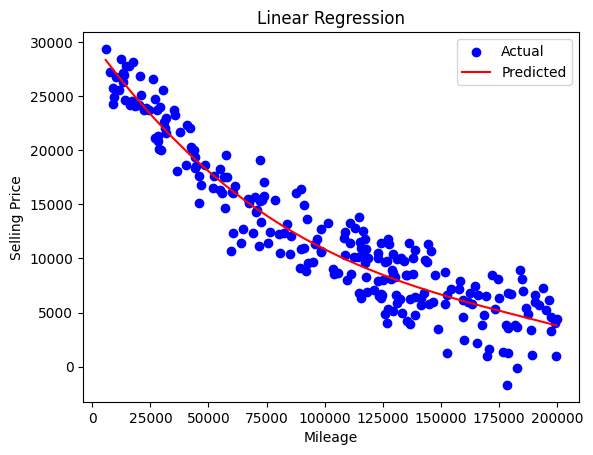

In [48]:
plt.scatter(x_train,y_train,color='b',label='Actual')
plt.plot(x_range[:, 0], y_range, color='r', label='Predicted')
plt.xlabel('Mileage')
plt.ylabel('Selling Price')
plt.title('Linear Regression')
plt.legend()
plt.show()


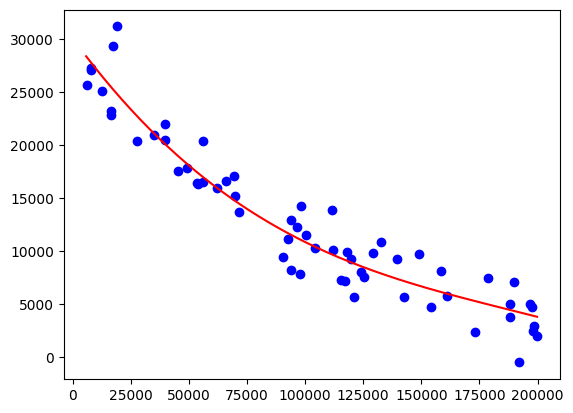

In [49]:
plt.scatter(x_test,y_test,color='b',label='Test Data')
plt.plot(x_range[:, 0], y_range, color='r', label='Predicted')

In [1]:
import pandas as pd
import seaborn as sns

df=pd.read_csv(r"C:\Users\Jeevan kumar\Downloads\student_data.csv")
df.sample(5)

,Name,Subject,Marks,Study_Hours,Age
3,Divya,DBMS,88,5,21
6,Gowri,AI,75,3,20
0,Anu,Python,85,2,18
1,Banu,AI,90,3,19
9,Jaya,Web,80,4,19


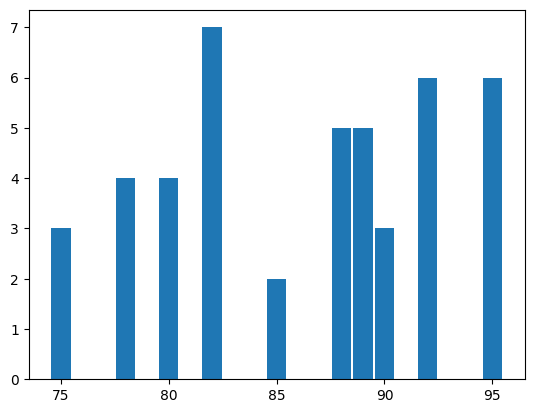

In [17]:
import matplotlib.pyplot as plt
plt.bar(df['Marks'],df["Study_Hours"],width=0.9)
plt.show()

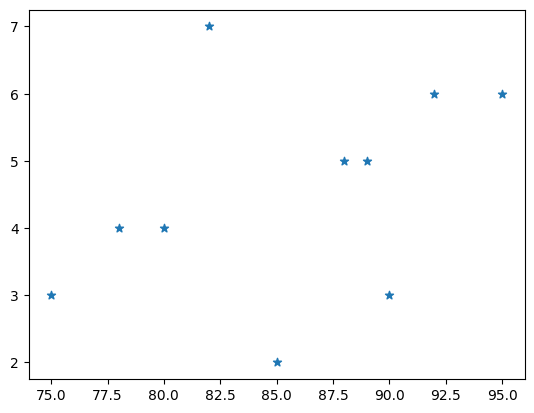

In [23]:
plt.scatter(df['Marks'],df["Study_Hours"],marker="*")
plt.show()

In [30]:
df.columns

Index(['Name', 'Subject', 'Marks', 'Study_Hours', 'Age'], dtype='str')

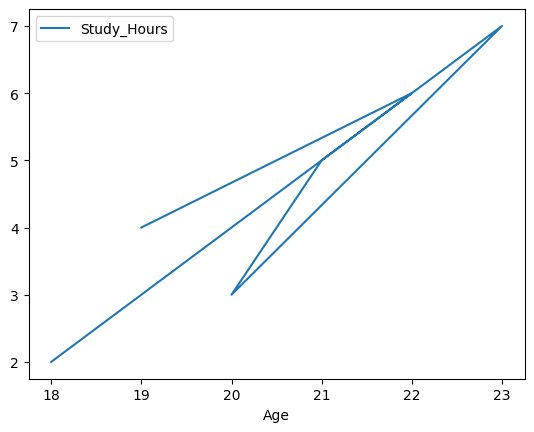

In [41]:
df.plot(x="Age",y="Study_Hours",kind="line")
plt.show()

In [35]:
df.sort_values("Age")

,Name,Subject,Marks,Study_Hours,Age
0,Anu,Python,85,2,18
1,Banu,AI,90,3,19
9,Jaya,Web,80,4,19
2,Charu,ML,78,4,20
6,Gowri,AI,75,3,20
3,Divya,DBMS,88,5,21
7,Hari,ML,89,5,21
4,Esha,Web,95,6,22
8,Isha,DBMS,92,6,22
5,Farah,Python,82,7,23


In [40]:
df.sort_values("Study_Hours")

,Name,Subject,Marks,Study_Hours,Age
0,Anu,Python,85,2,18
1,Banu,AI,90,3,19
6,Gowri,AI,75,3,20
2,Charu,ML,78,4,20
9,Jaya,Web,80,4,19
3,Divya,DBMS,88,5,21
7,Hari,ML,89,5,21
4,Esha,Web,95,6,22
8,Isha,DBMS,92,6,22
5,Farah,Python,82,7,23


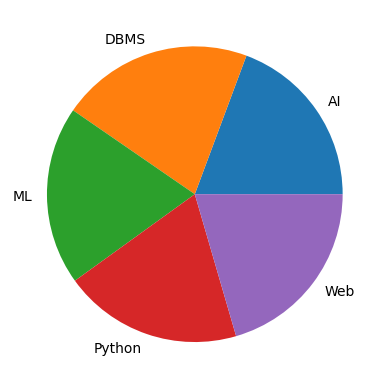

In [44]:
i=df.groupby("Subject")["Marks"].sum().plot(kind="pie")

In [43]:
i

Subject
AI        165
DBMS      180
ML        167
Python    167
Web       175
Name: Marks, dtype: int64

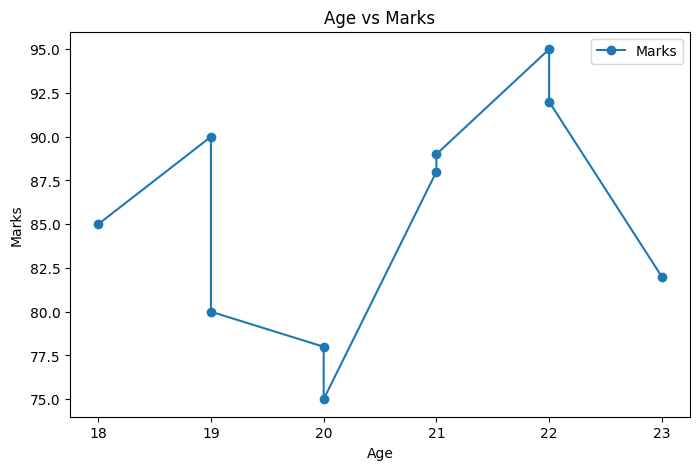

In [45]:
df.sort_values("Age").plot(
    x="Age",
    y="Marks",
    kind="line",
    marker="o",
    figsize=(8, 5),
    title="Age vs Marks"
)

plt.xlabel("Age")
plt.ylabel("Marks")
plt.show()